# CS 405/605 Final Project - Final Presentation Analysis

**Team:** DataPulse

**Research Question**

How are motion-based performance metrics related, and how do these relationships differ across activities in the Human Activity Recognition Using Smartphones dataset?

**Hypothesis**

There are statistically significant relationships between motion-based performance metrics, and those relationships vary across activities. Higher-intensity activities should show greater motion magnitude, variability, and stronger dynamic structure than lower-intensity activities.

**Final Analysis Goals**

- Build interpretable motion metrics from the raw inertial windows.
- Compare static and dynamic activities using magnitude, frequency, and directional features.
- Use regression to quantify how the metrics relate to one another.
- Evaluate whether the main relationships remain stable on the official holdout split.


## Project Alignment

This notebook is designed as the final analysis artifact for the project presentation and written report.

It aligns with the project requirements by:
- answering a specific research question
- testing a clear hypothesis
- using a real multivariate sensor dataset
- combining descriptive summaries, visual analysis, and regression modeling
- showing not only what patterns exist, but whether they remain stable on unseen data


## Dataset And Feature Strategy

Dataset: Human Activity Recognition Using Smartphones (UCI HAR)

Each observation is a 128-sample motion window recorded from smartphone accelerometer and gyroscope sensors while one of 30 subjects performed one of six activities:
- LAYING
- SITTING
- STANDING
- WALKING
- WALKING_UPSTAIRS
- WALKING_DOWNSTAIRS

Instead of using all 561 engineered HAR variables, this analysis focuses on a smaller raw-signal-derived feature set that is easier to interpret:
- **Intensity**: average acceleration magnitude
- **Variability**: standard deviation of acceleration magnitude
- **Rotational Intensity**: average gyroscope magnitude
- **Jerk Intensity**: average rate of acceleration change
- **Dominant Frequency**: strongest movement frequency in each window
- **Spectral Entropy**: frequency complexity of motion
- **Vertical / Horizontal Ratio**: directional emphasis of movement


## Imports, Paths, And Display Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

DATASET_DIR = Path('.')

SAMPLING_RATE_HZ = 50
DT = 1 / SAMPLING_RATE_HZ

ACTIVITY_ORDER = [
    'LAYING',
    'SITTING',
    'STANDING',
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS'
]

DISPLAY_LABELS = {
    'activity': 'Activity',
    'intensity': 'Acceleration Intensity',
    'variability': 'Acceleration Variability',
    'rotational_intensity': 'Rotational Intensity',
    'jerk_intensity': 'Jerk Intensity',
    'dominant_freq_hz': 'Dominant Frequency (Hz)',
    'spectral_entropy': 'Spectral Entropy',
    'vertical_horizontal_ratio': 'Vertical / Horizontal Motion Ratio',
    'split': 'Dataset Split'
}

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)

activity_labels = pd.read_csv(
    DATASET_DIR / 'activity_labels.txt',
    sep='\\s+',
    header=None,
    names=['activity_id', 'activity']
)
activity_map = dict(zip(activity_labels['activity_id'], activity_labels['activity']))


## Helper Functions

The next section converts raw accelerometer and gyroscope windows into interpretable features that can be summarized visually and modeled statistically.

In [2]:
def load_signal_matrix(path):
    return np.loadtxt(path)


def magnitude_from_xyz(x, y, z):
    return np.sqrt(x ** 2 + y ** 2 + z ** 2)


def jerk_from_magnitude(matrix, dt):
    return np.diff(matrix, axis=1) / dt


def rms(matrix):
    return np.sqrt(np.mean(matrix ** 2, axis=1))


def dominant_frequency(signal_matrix, sampling_rate_hz):
    centered = signal_matrix - signal_matrix.mean(axis=1, keepdims=True)
    fft_vals = np.fft.rfft(centered, axis=1)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(signal_matrix.shape[1], d=1 / sampling_rate_hz)
    power[:, 0] = 0.0
    peak_idx = np.argmax(power, axis=1)
    return freqs[peak_idx]


def spectral_entropy(signal_matrix):
    centered = signal_matrix - signal_matrix.mean(axis=1, keepdims=True)
    fft_vals = np.fft.rfft(centered, axis=1)
    power = np.abs(fft_vals) ** 2
    power_sum = power.sum(axis=1, keepdims=True)
    prob = power / np.where(power_sum == 0, 1.0, power_sum)
    entropy = -(prob * np.log2(np.where(prob > 0, prob, 1.0))).sum(axis=1)
    max_entropy = np.log2(power.shape[1])
    return entropy / max_entropy


def out_of_sample_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def build_split_df(split_name):
    split_dir = DATASET_DIR / split_name
    inertial_dir = split_dir / 'Inertial Signals'

    y = pd.read_csv(split_dir / f'y_{split_name}.txt', header=None, names=['activity_id'])
    subject = pd.read_csv(split_dir / f'subject_{split_name}.txt', header=None, names=['subject'])

    body_acc_x = load_signal_matrix(inertial_dir / f'body_acc_x_{split_name}.txt')
    body_acc_y = load_signal_matrix(inertial_dir / f'body_acc_y_{split_name}.txt')
    body_acc_z = load_signal_matrix(inertial_dir / f'body_acc_z_{split_name}.txt')
    body_gyro_x = load_signal_matrix(inertial_dir / f'body_gyro_x_{split_name}.txt')
    body_gyro_y = load_signal_matrix(inertial_dir / f'body_gyro_y_{split_name}.txt')
    body_gyro_z = load_signal_matrix(inertial_dir / f'body_gyro_z_{split_name}.txt')

    body_acc_mag = magnitude_from_xyz(body_acc_x, body_acc_y, body_acc_z)
    body_gyro_mag = magnitude_from_xyz(body_gyro_x, body_gyro_y, body_gyro_z)
    body_acc_jerk_mag = jerk_from_magnitude(body_acc_mag, DT)

    z_rms = rms(body_acc_z)
    horizontal_rms = np.sqrt(np.mean(body_acc_x ** 2 + body_acc_y ** 2, axis=1))
    vertical_horizontal_ratio = z_rms / (horizontal_rms + 1e-8)

    df = pd.DataFrame({
        'subject': subject['subject'],
        'activity_id': y['activity_id'],
        'activity': y['activity_id'].map(activity_map),
        'split': split_name,
        'intensity': body_acc_mag.mean(axis=1),
        'variability': body_acc_mag.std(axis=1),
        'rotational_intensity': body_gyro_mag.mean(axis=1),
        'jerk_intensity': body_acc_jerk_mag.mean(axis=1),
        'dominant_freq_hz': dominant_frequency(body_acc_mag, SAMPLING_RATE_HZ),
        'spectral_entropy': spectral_entropy(body_acc_mag),
        'vertical_horizontal_ratio': vertical_horizontal_ratio
    })

    df['activity'] = pd.Categorical(df['activity'], categories=ACTIVITY_ORDER, ordered=True)
    return df


def clustered_fit(formula, data):
    return smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data['subject']})


## Build The Analysis Tables

The dataset is kept in its official `train` and `test` partitions. The combined table is used for descriptive analysis and figures, while the split tables are used for holdout evaluation.

In [3]:
train_df = build_split_df('train')
test_df = build_split_df('test')
combined_df = pd.concat([train_df, test_df], ignore_index=True)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Combined shape:', combined_df.shape)

combined_df.groupby(['split', 'activity']).size().unstack(fill_value=0)


Train shape: (7352, 11)
Test shape: (2947, 11)
Combined shape: (10299, 11)


/var/folders/rv/0why5pjn05j4vt6579bnpqtm0000gn/T/ipykernel_2154/2184481528.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_df.groupby(['split', 'activity']).size().unstack(fill_value=0)


activity,LAYING,SITTING,STANDING,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS
split,,,,,,
test,537,491,532,496,471,420
train,1407,1286,1374,1226,1073,986


## Dataset Overview

This summary establishes the scope of the analysis and confirms that each activity is represented in the data.

In [4]:
overview = pd.DataFrame({
    'rows': [len(combined_df)],
    'subjects': [combined_df['subject'].nunique()],
    'activities': [combined_df['activity'].nunique()],
    'train_rows': [len(train_df)],
    'test_rows': [len(test_df)]
})
overview


,rows,subjects,activities,train_rows,test_rows
0,10299,30,6,7352,2947


## Window Structure Example

This section shows what one raw observation window contains.

**How to interpret it**
- One observation is a short synchronized sensor window rather than a single reading.
- Each window contains 128 time steps collected at 50 Hz.
- That corresponds to 2.56 seconds of motion.
- The raw channels are body acceleration and body gyroscope signals across the x, y, and z axes.

**Why it matters**
This gives a concrete view of the data structure behind the derived features such as intensity, dominant frequency, and directional motion ratio.

In [5]:
window_info = pd.DataFrame({
    'sampling_rate_hz': [SAMPLING_RATE_HZ],
    'window_samples': [128],
    'window_duration_seconds': [round(128 / SAMPLING_RATE_HZ, 2)],
    'sensor_channels': [6],
    'channel_names': ['body_acc_x, body_acc_y, body_acc_z, body_gyro_x, body_gyro_y, body_gyro_z']
})

train_inertial_dir = DATASET_DIR / 'train' / 'Inertial Signals'
example_window = pd.DataFrame({
    'sample_index': np.arange(1, 9),
    'body_acc_x': load_signal_matrix(train_inertial_dir / 'body_acc_x_train.txt')[0, :8],
    'body_acc_y': load_signal_matrix(train_inertial_dir / 'body_acc_y_train.txt')[0, :8],
    'body_acc_z': load_signal_matrix(train_inertial_dir / 'body_acc_z_train.txt')[0, :8],
    'body_gyro_x': load_signal_matrix(train_inertial_dir / 'body_gyro_x_train.txt')[0, :8],
    'body_gyro_y': load_signal_matrix(train_inertial_dir / 'body_gyro_y_train.txt')[0, :8],
    'body_gyro_z': load_signal_matrix(train_inertial_dir / 'body_gyro_z_train.txt')[0, :8]
}).round(4)

display(window_info)
display(example_window)


,sampling_rate_hz,window_samples,window_duration_seconds,sensor_channels,channel_names
0,50,128,2.56,6,"body_acc_x, body_acc_y, body_acc_z, body_gyro_..."


,sample_index,body_acc_x,body_acc_y,body_acc_z,body_gyro_x,body_gyro_y,body_gyro_z
0,1,0.0002,0.0108,0.0556,0.0302,0.0660,0.0229
1,2,0.0101,0.0066,0.0551,0.0437,0.0427,0.0103
2,3,0.0093,0.0089,0.0484,0.0357,0.0749,0.0132
3,4,0.0051,0.0075,0.0498,0.0404,0.0573,0.0178
4,5,0.0108,0.0061,0.0430,0.0471,0.0523,0.0026
5,6,0.0040,0.0069,0.0447,0.0502,0.0692,0.0077
6,7,0.0048,0.0036,0.0437,0.0505,0.0499,0.0043
7,8,0.0062,0.0025,0.0354,0.0450,0.0568,0.0106


## Activity-Level Summary Statistics

These mean values give the first direct answer to the research question by showing how the motion metrics differ across activities.

In [6]:
summary_cols = [
    'intensity',
    'variability',
    'rotational_intensity',
    'jerk_intensity',
    'dominant_freq_hz',
    'spectral_entropy',
    'vertical_horizontal_ratio'
]

activity_summary = combined_df.groupby('activity', observed=False)[summary_cols].agg(['mean', 'std']).round(4)
activity_summary


intensity         variability         rotational_intensity  \
                        mean     std        mean     std                 mean   
activity                                                                        
LAYING                0.0243  0.0496      0.0143  0.0313               0.0636   
SITTING               0.0197  0.0297      0.0130  0.0246               0.0556   
STANDING              0.0198  0.0213      0.0117  0.0147               0.0600   
WALKING               0.2878  0.0456      0.1233  0.0262               0.7045   
WALKING_UPSTAIRS      0.3108  0.0491      0.1394  0.0249               0.7978   
WALKING_DOWNSTAIRS    0.3795  0.0717      0.2066  0.0372               0.8447   

                           jerk_intensity         dominant_freq_hz          \
                       std           mean     std             mean     std   
activity                                                                     
LAYING              0.0931        -0.0071  0.0384           1.2022  1.5498   
SITTING             0.0826        -0.0071  0.0317           1.1994  1.4643   
STANDING            0.0682        -0.0033  0.0166           0.9942  1.1915   
WALKING             0.1767        -0.0019  0.0727           2.4125  1.2965   
WALKING_UPSTAIRS    0.1915         0.0024  0.0797           2.4369  0.9743   
WALKING_DOWNSTAIRS  0.1994         0.0035  0.1157           2.9703  1.0331   

                   spectral_entropy         vertical_horizontal_ratio          
                               mean     std                      mean     std  
activity                                                                       
LAYING                       0.6179  0.1790                    0.7798  0.3970  
SITTING                      0.6454  0.1606                    1.1530  0.4652  
STANDING                     0.6286  0.1452                    1.0401  0.4415  
WALKING                      0.6922  0.0540                    0.4864  0.1517  
WALKING_UPSTAIRS             0.6198  0.0650                    0.5140  0.1532  
WALKING_DOWNSTAIRS           0.6493  0.0599                    0.3767  0.1149

## Visualization 1: Intensity By Activity

This figure compares overall movement magnitude across the six activities.

**How to interpret it**
- Higher values indicate greater average acceleration magnitude.
- Static activities should cluster near the bottom.
- Walking-related activities should appear clearly higher if the hypothesis is supported.

**Why it matters**
This is the clearest visual test of whether dynamic activities involve more motion than static ones.

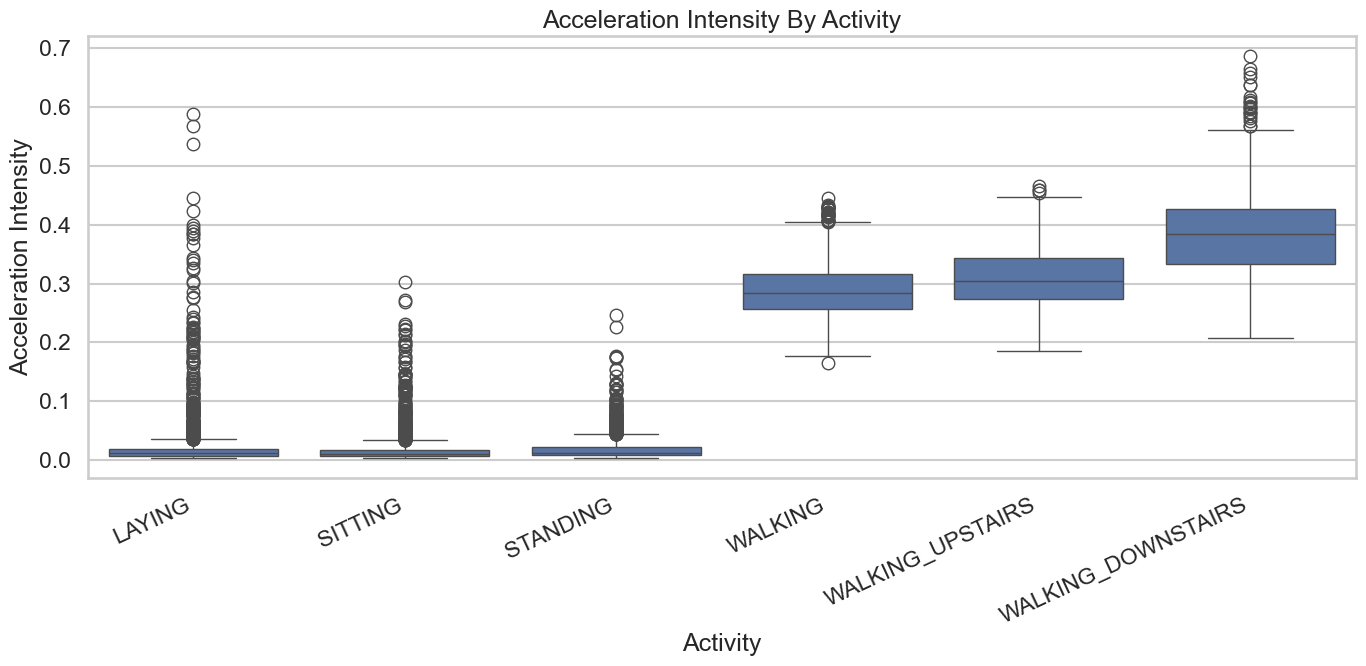

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=combined_df, x='activity', y='intensity', order=ACTIVITY_ORDER)
plt.title('Acceleration Intensity By Activity')
plt.xlabel(DISPLAY_LABELS['activity'])
plt.ylabel(DISPLAY_LABELS['intensity'])
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## Visualization 2: Dominant Frequency By Activity

This figure shows how motion cadence differs across activities.

**How to interpret it**
- Static activities should have low or near-zero dominant frequency.
- Walking-related activities should show stronger periodic structure.
- Differences among the walking classes suggest that rhythm helps distinguish subclasses of movement.

**Why it matters**
This moves the analysis beyond movement amount and into movement timing.

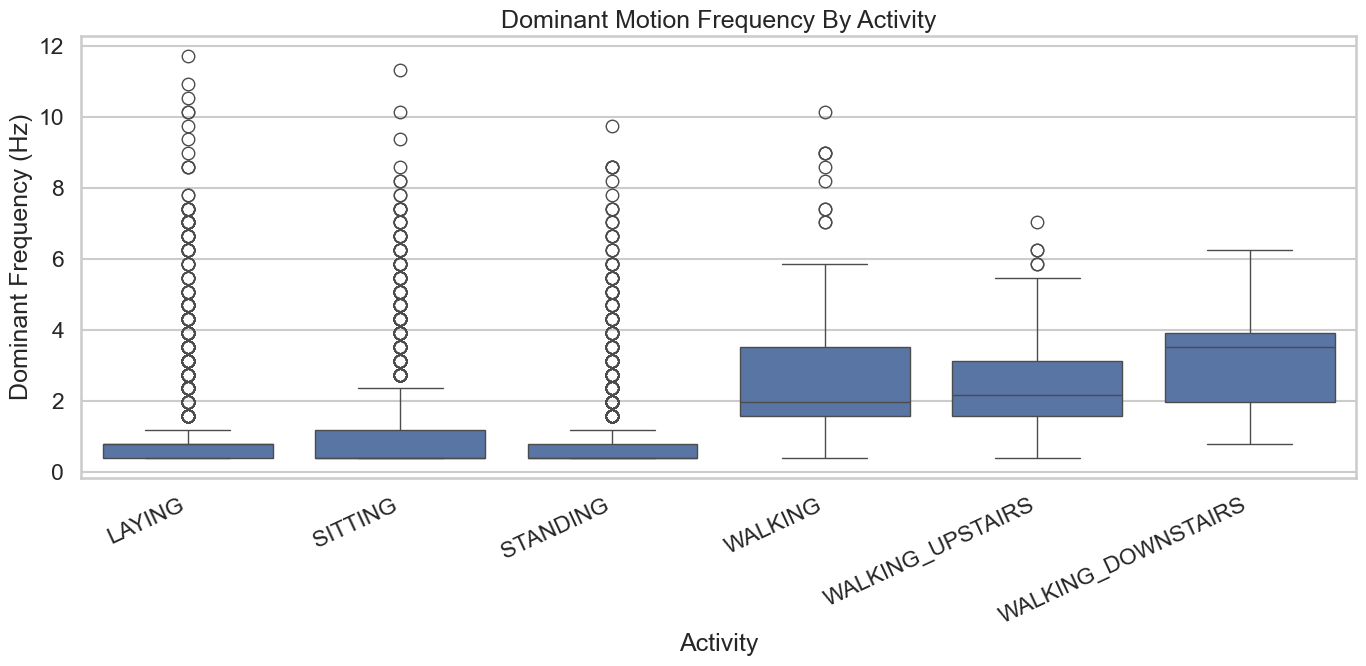

In [8]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=combined_df, x='activity', y='dominant_freq_hz', order=ACTIVITY_ORDER)
plt.title('Dominant Motion Frequency By Activity')
plt.xlabel(DISPLAY_LABELS['activity'])
plt.ylabel(DISPLAY_LABELS['dominant_freq_hz'])
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## Visualization 3: Vertical Versus Horizontal Motion Ratio By Activity

This figure compares the directional structure of movement.

**How to interpret it**
- Higher values indicate relatively more vertical motion.
- Lower values indicate relatively more horizontal motion.
- Separation across activities suggests that movement direction contributes meaningful information beyond magnitude.

**Why it matters**
It helps distinguish how movement is organized, not only how much movement occurs.

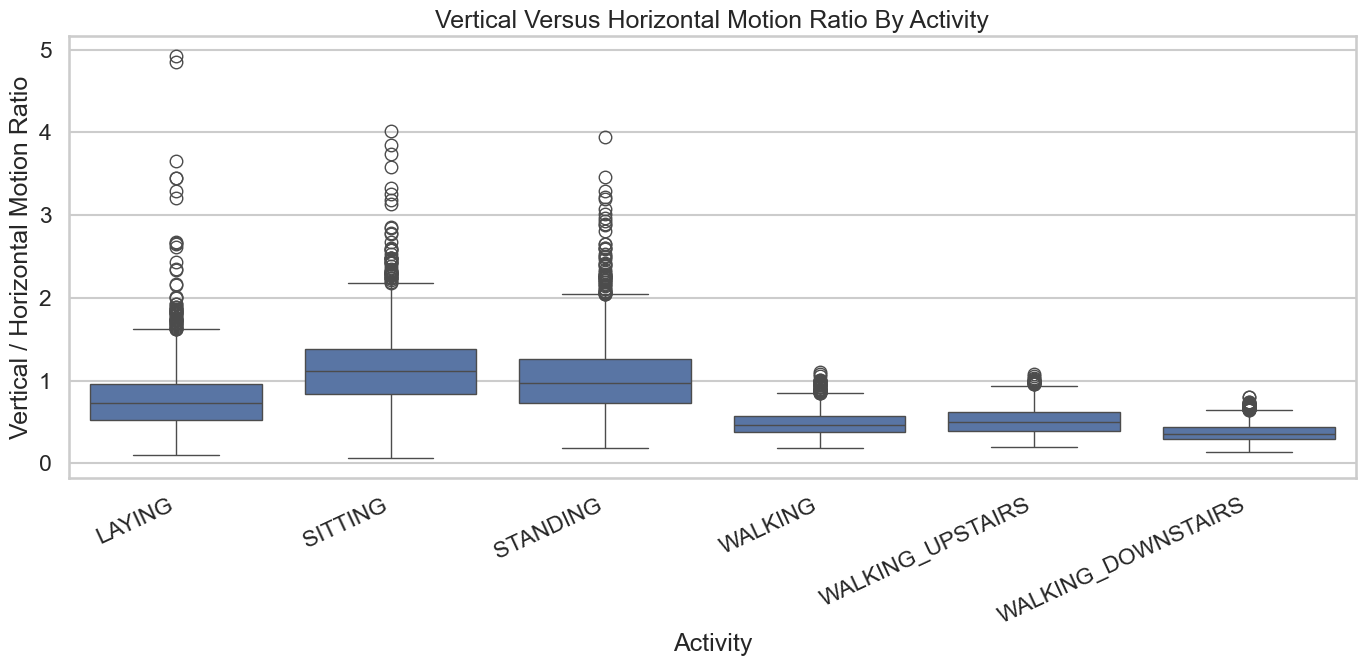

In [9]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=combined_df, x='activity', y='vertical_horizontal_ratio', order=ACTIVITY_ORDER)
plt.title('Vertical Versus Horizontal Motion Ratio By Activity')
plt.xlabel(DISPLAY_LABELS['activity'])
plt.ylabel(DISPLAY_LABELS['vertical_horizontal_ratio'])
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## Visualization 4: Frequency Versus Direction Scatterplot

This combines two of the most distinctive features in one figure.

**How to interpret it**
- Each point is one motion window.
- The x-axis captures movement rhythm.
- The y-axis captures directional emphasis.
- If activity colors cluster in different regions, that means the metrics separate behavior types well.

**Why it matters**
This is a strong presentation figure because it shows two complementary dimensions of movement style at once.

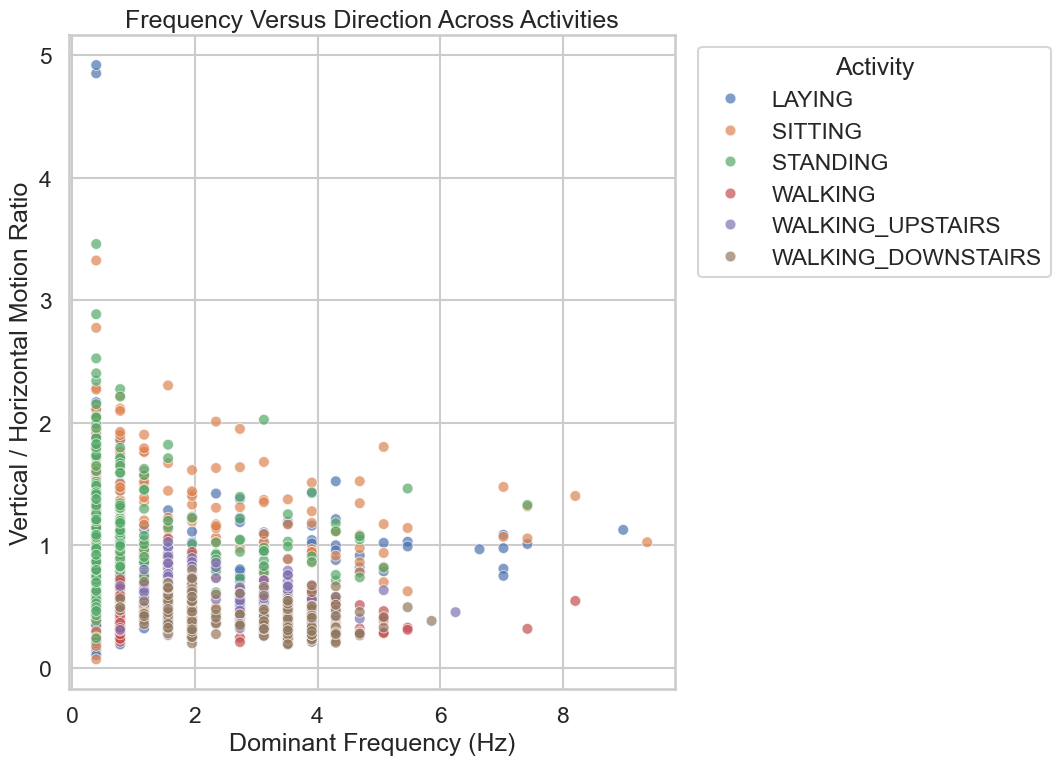

In [10]:
plot_parts = []
for _, df in combined_df.groupby('activity', observed=False):
    plot_parts.append(df.sample(n=min(len(df), 300), random_state=42))
plot_df = pd.concat(plot_parts, ignore_index=True)

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_df,
    x='dominant_freq_hz',
    y='vertical_horizontal_ratio',
    hue='activity',
    hue_order=ACTIVITY_ORDER,
    alpha=0.7,
    s=60
)
plt.title('Frequency Versus Direction Across Activities')
plt.xlabel(DISPLAY_LABELS['dominant_freq_hz'])
plt.ylabel(DISPLAY_LABELS['vertical_horizontal_ratio'])
plt.legend(title=DISPLAY_LABELS['activity'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Visualization 5: Correlation Heatmap

This figure shows how strongly the selected metrics are related to one another.

**How to interpret it**
- Strong positive correlations indicate metrics that tend to rise together.
- We expect intensity, variability, rotational intensity, and jerk to be related.
- Features such as dominant frequency, spectral entropy, and direction are valuable when they add information that is less redundant.

**Why it matters**
This helps justify the chosen feature set and supports the claim that the analysis captures more than simple movement magnitude.

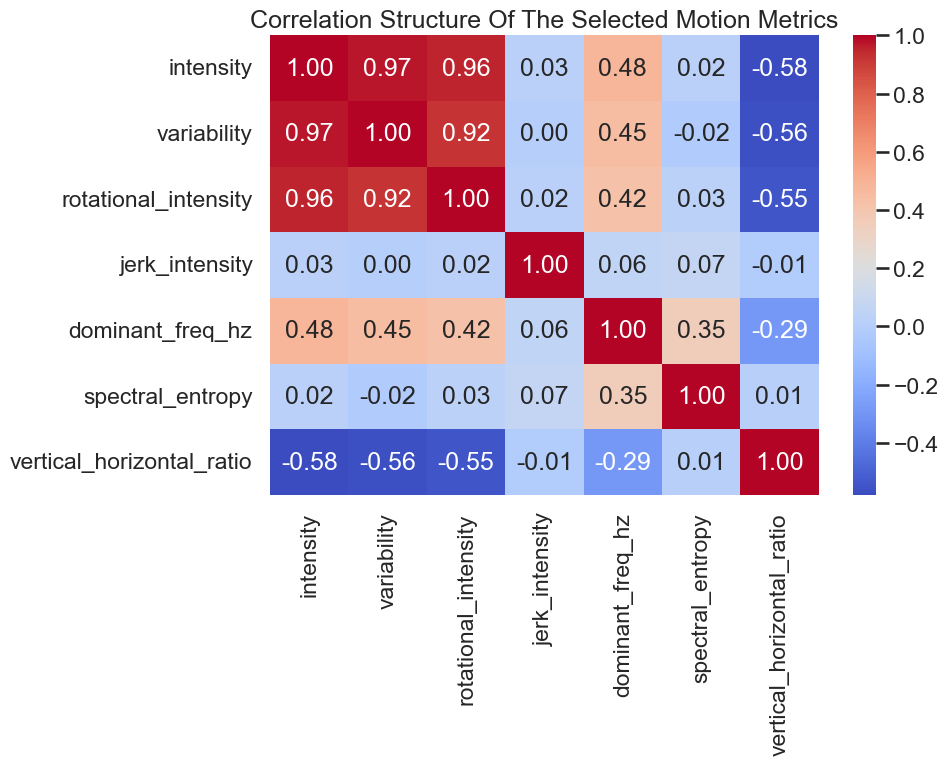

In [11]:
corr_matrix = combined_df[summary_cols].corr().round(3)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Structure Of The Selected Motion Metrics')
plt.tight_layout()
plt.show()


## Modeling Strategy

The visual analysis shows how activities differ. The next step is to quantify the relationships.

Two regression models are used:
- an **intensity model** to explain overall movement magnitude
- a **direction model** to explain vertical versus horizontal motion emphasis

The main model is fit on the official training split and evaluated on the official test split. This holdout check asks whether the relationships remain stable on unseen data.

Clustered standard errors by subject are used because each subject contributes many windows, so observations within a subject are not fully independent.

## Intensity Model: Fit On Train, Evaluate On Test

This model asks how intensity relates to variability, rotation, jerk, frequency, entropy, direction, and activity.

**Why this model matters**
- It tests the core hypothesis about relationships among motion metrics.
- It shows whether additional motion-style variables contribute beyond simple magnitude summaries.
- It provides a direct holdout evaluation using unseen test windows.

In [12]:
intensity_formula = (
    'intensity ~ variability + rotational_intensity + jerk_intensity + '
    'dominant_freq_hz + spectral_entropy + vertical_horizontal_ratio + C(activity)'
)

train_intensity_model = clustered_fit(intensity_formula, train_df)
test_intensity_predictions = train_intensity_model.predict(test_df)

intensity_metrics = pd.DataFrame([
    {
        'split': 'train_fit',
        'r2': train_intensity_model.rsquared,
        'mae': np.mean(np.abs(train_df['intensity'] - train_intensity_model.fittedvalues)),
        'rmse': np.sqrt(np.mean((train_df['intensity'] - train_intensity_model.fittedvalues) ** 2))
    },
    {
        'split': 'test_holdout',
        'r2': out_of_sample_r2(test_df['intensity'].to_numpy(), test_intensity_predictions.to_numpy()),
        'mae': np.mean(np.abs(test_df['intensity'] - test_intensity_predictions)),
        'rmse': np.sqrt(np.mean((test_df['intensity'] - test_intensity_predictions) ** 2))
    }
]).round(4)

display(intensity_metrics)
display(train_intensity_model.summary().tables[1])


,split,r2,mae,rmse
0,train_fit,0.9757,0.0145,0.0254
1,test_holdout,0.9818,0.0133,0.0202


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.0078,0.005,1.440,0.150,-0.003,0.018
C(activity)[T.SITTING],-0.0025,0.004,-0.692,0.489,-0.010,0.005
C(activity)[T.STANDING],-0.0008,0.003,-0.246,0.806,-0.007,0.006
C(activity)[T.WALKING],0.0824,0.018,4.554,0.000,0.047,0.118
C(activity)[T.WALKING_UPSTAIRS],0.0833,0.019,4.346,0.000,0.046,0.121
C(activity)[T.WALKING_DOWNSTAIRS],0.0686,0.026,2.675,0.007,0.018,0.119
variability,1.1639,0.128,9.063,0.000,0.912,1.416
rotational_intensity,0.0770,0.018,4.228,0.000,0.041,0.113
jerk_intensity,0.0082,0.007,1.105,0.269,-0.006,0.023
dominant_freq_hz,0.0034,0.001,3.988,0.000,0.002,0.005


## Visualization 6: Holdout Predictions Versus Observed Intensity

This figure visualizes the holdout check.

**How to interpret it**
- Each point is a test-split motion window.
- The dashed diagonal represents perfect prediction.
- Points close to the line indicate that the model generalizes well.
- Activity color helps show whether performance differs by behavior type.

**Why it matters**
This turns the holdout evaluation into a presentation-friendly visual instead of relying only on fit statistics.

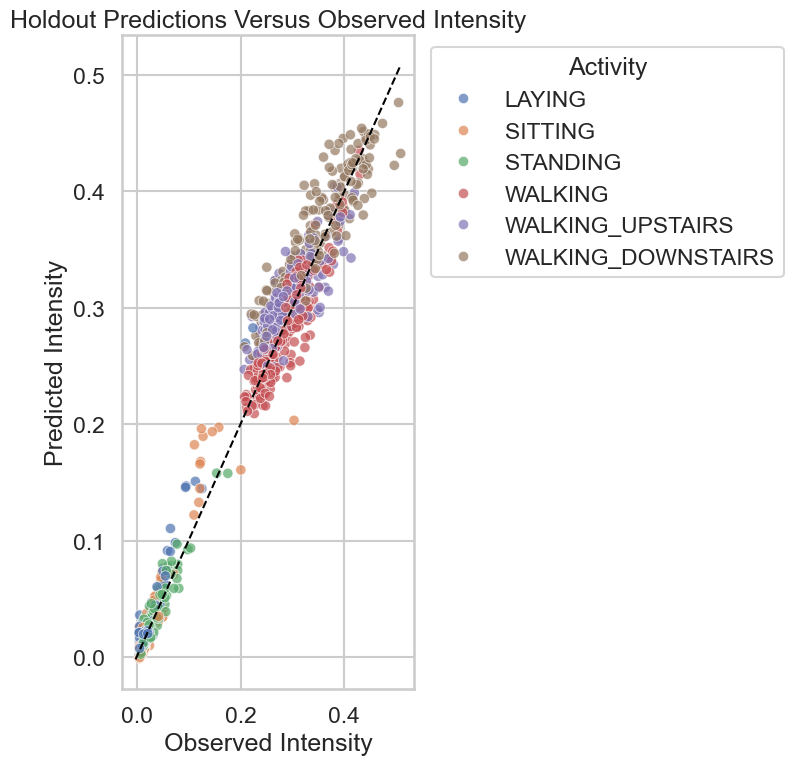

In [13]:
holdout_df = test_df.copy()
holdout_df['predicted_intensity'] = test_intensity_predictions

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=holdout_df.sample(n=min(len(holdout_df), 1500), random_state=42),
    x='intensity',
    y='predicted_intensity',
    hue='activity',
    hue_order=ACTIVITY_ORDER,
    alpha=0.7,
    s=55
)
line_min = min(holdout_df['intensity'].min(), holdout_df['predicted_intensity'].min())
line_max = max(holdout_df['intensity'].max(), holdout_df['predicted_intensity'].max())
plt.plot([line_min, line_max], [line_min, line_max], color='black', linestyle='--', linewidth=1.5)
plt.title('Holdout Predictions Versus Observed Intensity')
plt.xlabel('Observed Intensity')
plt.ylabel('Predicted Intensity')
plt.legend(title=DISPLAY_LABELS['activity'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Direction Model: Fit On Train, Evaluate On Test

This model treats the vertical / horizontal ratio as the outcome.

**Why this model matters**
- It tests whether directional movement is systematically related to frequency and motion dynamics.
- It shows that direction is a meaningful analysis target, not just a visualization feature.
- It broadens the project beyond a single magnitude-based outcome.

In [14]:
direction_formula = (
    'vertical_horizontal_ratio ~ dominant_freq_hz + spectral_entropy + '
    'rotational_intensity + jerk_intensity + C(activity)'
)

train_direction_model = clustered_fit(direction_formula, train_df)
test_direction_predictions = train_direction_model.predict(test_df)

direction_metrics = pd.DataFrame([
    {
        'split': 'train_fit',
        'r2': train_direction_model.rsquared,
        'mae': np.mean(np.abs(train_df['vertical_horizontal_ratio'] - train_direction_model.fittedvalues)),
        'rmse': np.sqrt(np.mean((train_df['vertical_horizontal_ratio'] - train_direction_model.fittedvalues) ** 2))
    },
    {
        'split': 'test_holdout',
        'r2': out_of_sample_r2(test_df['vertical_horizontal_ratio'].to_numpy(), test_direction_predictions.to_numpy()),
        'mae': np.mean(np.abs(test_df['vertical_horizontal_ratio'] - test_direction_predictions)),
        'rmse': np.sqrt(np.mean((test_df['vertical_horizontal_ratio'] - test_direction_predictions) ** 2))
    }
]).round(4)

display(direction_metrics)
display(train_direction_model.summary().tables[1])


,split,r2,mae,rmse
0,train_fit,0.4188,0.2284,0.3420
1,test_holdout,0.4443,0.2148,0.3141


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.6662,0.083,8.055,0.000,0.504,0.828
C(activity)[T.SITTING],0.3615,0.081,4.460,0.000,0.203,0.520
C(activity)[T.STANDING],0.2461,0.077,3.193,0.001,0.095,0.397
C(activity)[T.WALKING],-0.3824,0.096,-3.976,0.000,-0.571,-0.194
C(activity)[T.WALKING_UPSTAIRS],-0.3555,0.094,-3.774,0.000,-0.540,-0.171
C(activity)[T.WALKING_DOWNSTAIRS],-0.5173,0.101,-5.100,0.000,-0.716,-0.319
dominant_freq_hz,-0.0069,0.006,-1.231,0.218,-0.018,0.004
spectral_entropy,0.2168,0.091,2.371,0.018,0.038,0.396
rotational_intensity,0.1221,0.114,1.069,0.285,-0.102,0.346
jerk_intensity,0.1182,0.047,2.514,0.012,0.026,0.210


## Coefficient Stability Table

This compares the intensity-model coefficients estimated separately on the train and test splits.

**How to interpret it**
- `same_sign = True` means the direction of the relationship is consistent across splits.
- Smaller `abs_diff` values indicate more stable coefficient magnitude.
- Stable coefficients make the interpretation more credible.

**Why it matters**
The final presentation should not only show that the model fits, but also that the interpreted relationships are reasonably stable.

In [15]:
test_intensity_model = clustered_fit(intensity_formula, test_df)

coef_compare = pd.DataFrame({
    'train_coef': train_intensity_model.params,
    'test_coef': test_intensity_model.params,
    'train_pvalue': train_intensity_model.pvalues,
    'test_pvalue': test_intensity_model.pvalues
})
coef_compare['same_sign'] = np.sign(coef_compare['train_coef']) == np.sign(coef_compare['test_coef'])
coef_compare['abs_diff'] = (coef_compare['test_coef'] - coef_compare['train_coef']).abs()
coef_compare.round(4)


,train_coef,test_coef,train_pvalue,test_pvalue,same_sign,abs_diff
Intercept,0.0078,0.0004,0.1500,0.9237,True,0.0074
C(activity)[T.SITTING],-0.0025,0.0007,0.4891,0.4435,False,0.0032
C(activity)[T.STANDING],-0.0008,0.0024,0.8057,0.0112,False,0.0032
C(activity)[T.WALKING],0.0824,0.0844,0.0000,0.0000,True,0.0020
C(activity)[T.WALKING_UPSTAIRS],0.0833,0.0697,0.0000,0.0000,True,0.0136
C(activity)[T.WALKING_DOWNSTAIRS],0.0686,0.0588,0.0075,0.0007,True,0.0098
variability,1.1639,1.0796,0.0000,0.0000,True,0.0844
rotational_intensity,0.0770,0.0941,0.0000,0.0000,True,0.0171
jerk_intensity,0.0082,0.0210,0.2694,0.0190,True,0.0128
dominant_freq_hz,0.0034,0.0039,0.0001,0.0011,True,0.0005


## Per-Activity Relationship Summary

The final question is whether the internal relationships differ across activities.

This table fits a simpler intensity model within each activity and compares the main coefficients. It helps separate the broad static-versus-dynamic contrast from more specific within-activity behavior.

In [16]:
activity_formula = (
    'intensity ~ variability + rotational_intensity + jerk_intensity + '
    'dominant_freq_hz + spectral_entropy + vertical_horizontal_ratio'
)

rows = []
for activity in ACTIVITY_ORDER:
    subset = combined_df[combined_df['activity'] == activity]
    model = smf.ols(activity_formula, data=subset).fit()
    rows.append({
        'activity': activity,
        'n_windows': len(subset),
        'r2': model.rsquared,
        'variability_coef': model.params.get('variability', np.nan),
        'rotational_coef': model.params.get('rotational_intensity', np.nan),
        'jerk_coef': model.params.get('jerk_intensity', np.nan),
        'frequency_coef': model.params.get('dominant_freq_hz', np.nan),
        'direction_coef': model.params.get('vertical_horizontal_ratio', np.nan)
    })

per_activity_summary = pd.DataFrame(rows).round(4)
per_activity_summary


,activity,n_windows,r2,variability_coef,rotational_coef,jerk_coef,frequency_coef,direction_coef
0,LAYING,1944,0.7484,1.2790,0.0716,0.2080,0.0007,0.0062
1,SITTING,1777,0.9236,1.1271,0.0459,0.1058,0.0002,0.0001
2,STANDING,1906,0.9316,1.0642,0.0811,-0.0499,0.0001,0.0014
3,WALKING,1722,0.7593,1.0730,0.0733,-0.0049,0.0057,-0.0022
4,WALKING_UPSTAIRS,1544,0.7099,0.9913,0.1163,0.0034,0.0056,-0.0280
5,WALKING_DOWNSTAIRS,1406,0.7893,1.2806,0.0944,-0.0139,0.0108,-0.1408


## Final Findings

When you present the results, the main takeaways to emphasize are:

- Dynamic activities should show clearly higher intensity, variability, rotational motion, and jerk than static activities.
- Dominant frequency should distinguish rhythmic activities, especially walking-related classes, from static behaviors.
- The vertical / horizontal ratio should show that activities differ not only in how much they move, but also in the direction of motion.
- The correlation heatmap should show that some motion metrics rise together, while frequency and directional metrics add more specialized information.
- The holdout evaluation should show whether the core regression relationships remain stable on unseen data.

Together, these results answer the research question by showing that activities differ in both movement amount and movement structure.